* check the thermalization and autocorrelations for the given parameters

* using the n_therm and the n_meas, look at the outputs of the nested sampling of CPN

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt

import glob

In [2]:
L, T = 72, 72
V = L*T

N = 21
beta = 0.6

n_cool_step = 50     # number of cooling steps 
meas_cool_every = 5
skip_topo = n_cool_step // meas_cool_every + 1

# action prefactor 
pf = 2#beta #*N*V

In [3]:
# for the long runs
n_live = 50
n_iter = 10
n_live_eff = n_iter * n_live

In [6]:
# long run, 1+1rep so far
# dir_list = sorted(glob.glob("out_data/res*"))
# d0=4  # dirlist index to exclude some
# quick and dirty runs
# dir_list = sorted(glob.glob("out_data/ns_constraint_72_N21_4x2000_stoc5000/run_*")+glob.glob("out_data/ns_constraint_72_N21_4x500_stoc5000/run_*"))
dir_list = sorted(glob.glob("out_data_ubelix/run_*"))

d0=0

gen_df  = "dati.dat"
topo_df = "topo.dat"
accr_df = "acceptance_rate.dat"
dir_list

['out_data_ubelix\\run_0',
 'out_data_ubelix\\run_1',
 'out_data_ubelix\\run_2',
 'out_data_ubelix\\run_3',
 'out_data_ubelix\\run_4',
 'out_data_ubelix\\run_5',
 'out_data_ubelix\\run_6',
 'out_data_ubelix\\run_7',
 'out_data_ubelix\\run_8',
 'out_data_ubelix\\run_9']

In [7]:
""" 
the cols in the files are: 
gen_data:
    [0]: Conf. update index
    [1]: energy density S/(2NVb)
    [2]: magn_susc G(p=0)
    [3]: magn_susc G(p=q) => get corr length ~ G(q)/G(0)

topo_data:
    [0]: Conf. update index
    [1]: cooling step
    [2]: geom. top.charge Q_U
    [3]: geom. magn_susc_U
    [4]: geom. top.charge Q_z
    [5]: geom. magn_susc_z
    [6]: non-geom topo charge ~ plaquette
    [7]: non-geom topo susc ~ plaquette
"""

' \nthe cols in the files are: \ngen_data:\n    [0]: Conf. update index\n    [1]: energy density S/(2NVb)\n    [2]: magn_susc G(p=0)\n    [3]: magn_susc G(p=q) => get corr length ~ G(q)/G(0)\n\ntopo_data:\n    [0]: Conf. update index\n    [1]: cooling step\n    [2]: geom. top.charge Q_U\n    [3]: geom. magn_susc_U\n    [4]: geom. top.charge Q_z\n    [5]: geom. magn_susc_z\n    [6]: non-geom topo charge ~ plaquette\n    [7]: non-geom topo susc ~ plaquette\n'

# Load data into combined list

In [8]:
gen_data = []
topo_data = []
acc_rates = []

cutoff = -1 #8000

for d in dir_list[d0:]:
   gen_data.append(np.loadtxt(os.path.join(d,gen_df))[:cutoff])
   topo_data.append(np.loadtxt(os.path.join(d,topo_df))[:cutoff*skip_topo]) 
   acc_rates.append(np.loadtxt(os.path.join(d,accr_df)))

In [9]:
gen_data  = np.concatenate(gen_data, axis=0)
topo_data = np.concatenate(topo_data, axis=0)
accr_data = np.concatenate(acc_rates, axis=0)

print(gen_data.shape, "\n", topo_data.shape, "\n", accr_data.shape)

(39458, 4) 
 (434038, 8) 
 (39458, 4)


In [10]:
print(topo_data[::skip_topo].shape)

(39458, 8)


In [11]:
order = np.argsort(gen_data[:,1])[::-1]   # sort after the action vals, from largest to smallest

print(gen_data[:,1][order][:10])

[0.86757453 0.86716537 0.86574708 0.86518779 0.86457205 0.86435217
 0.86415671 0.86414824 0.86403085 0.86401659]


In [12]:
## for gen_data~[N, m], topo_data~[N*skip_topo, k]:
gen_sorted = gen_data[order]

# reshape topo_data into (N, skip_topo, k)
topo_blocks = topo_data.reshape(len(gen_data), skip_topo, -1)

# reorder the blocks
topo_sorted = topo_blocks[order]

# if needed, flatten back to the original shape
topo_sorted = topo_sorted.reshape(-1, topo_data.shape[1])

print(gen_sorted.shape, "\n", topo_sorted.shape)

(39458, 4) 
 (434038, 8)


In [13]:
## for accr~[N, m]:
accr_sorted = accr_data[order[:len(accr_data)]]

print(accr_sorted.shape)

(39458, 4)


are we a little skewed because we did not stop?


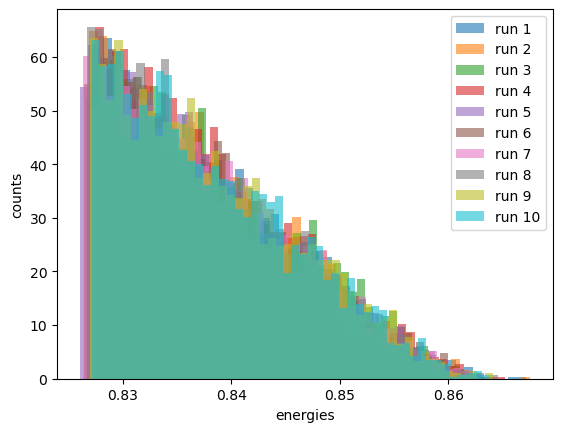

Text(0.5, 1.0, 'Combined energy list')

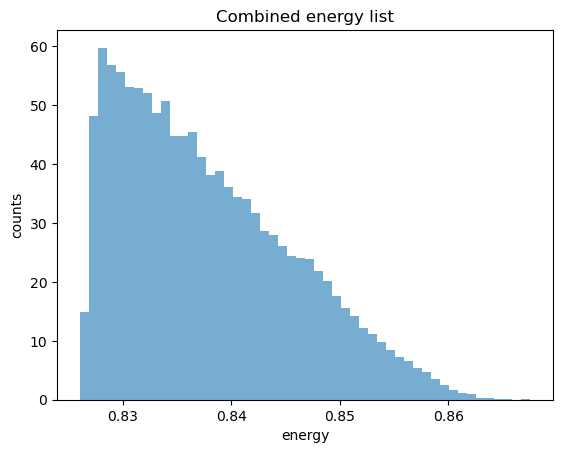

In [14]:
# look at different-run energies: => Achtugn, denisty=True!
run_nr = 1
for d in dir_list[d0:]:
   s = np.loadtxt(os.path.join(d,gen_df))[:,1]
   #s = s[:int(1*len(s)//2)]
   _=plt.hist(s, bins=50, alpha=0.6, label=f"run {run_nr}", density=True)
   run_nr += 1

plt.legend()
plt.xlabel("energies")
plt.ylabel("counts")

print("are we a little skewed because we did not stop?")
plt.show()

# at the sorted total run energy:
_=plt.hist(gen_sorted[:,1], bins=50, alpha=0.6, label=f"run {run_nr}", density=True)
plt.xlabel("energy")
plt.ylabel("counts")
plt.title("Combined energy list")

# acceptance rates

Text(0.5, 0, 'Nested sampling steps')

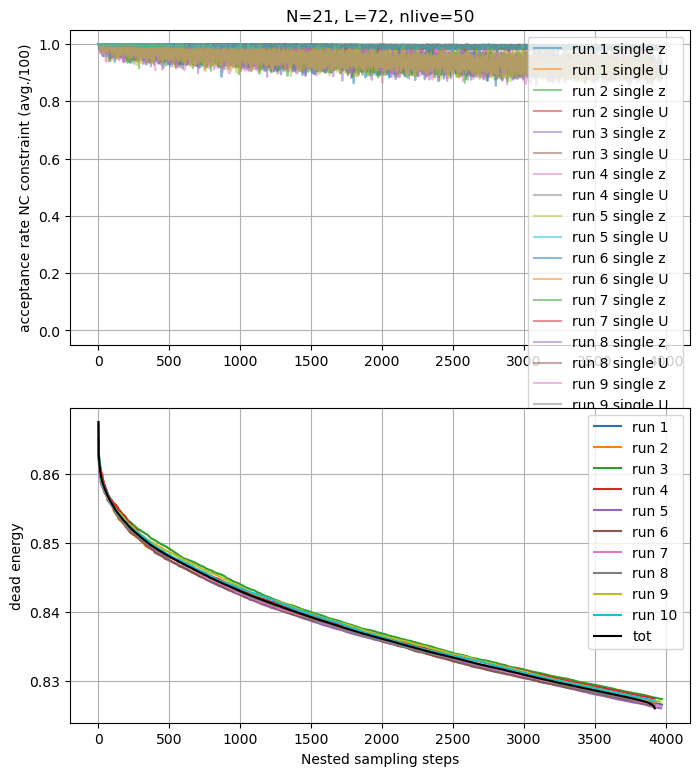

In [15]:
fig, axs = plt.subplots(2, 1, figsize=(8, 9))

# look at different-run energies:
run_nr = 1
for d in dir_list[d0:]:
    data = np.loadtxt(os.path.join(d,accr_df))

    axs[0].plot(data[:,1], label=f"run {run_nr} single z", alpha=0.5)
    axs[0].plot(data[:,2], label=f"run {run_nr} single U", alpha=0.5)

    s = np.loadtxt(os.path.join(d,gen_df))

    axs[1].plot(s[:,1], label=f"run {run_nr}")

    run_nr += 1

axs[1].plot(np.linspace(0,1,len(gen_sorted))*len(s), gen_sorted[:,1], label=f"tot", color="black")    
    
axs[0].set_ylabel("acceptance rate NC constraint (avg./100)")
axs[0].grid()
axs[0].legend()
axs[0].set_ylim(-0.05,1.05)

axs[1].set_ylabel("dead energy")
axs[1].grid()
axs[1].legend()

axs[0].set_title("N=21, L=72, nlive=50")
axs[1].set_xlabel("Nested sampling steps")

# look at data

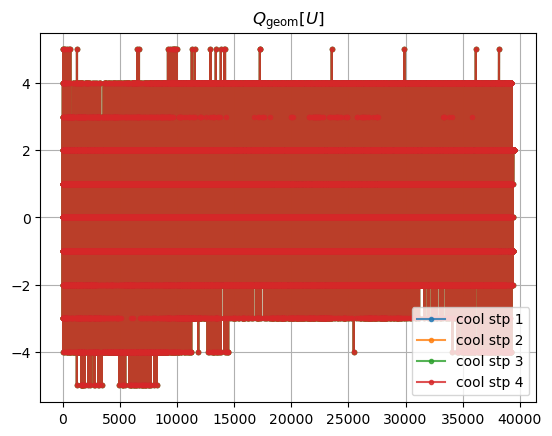

(-5.0, 5.0)

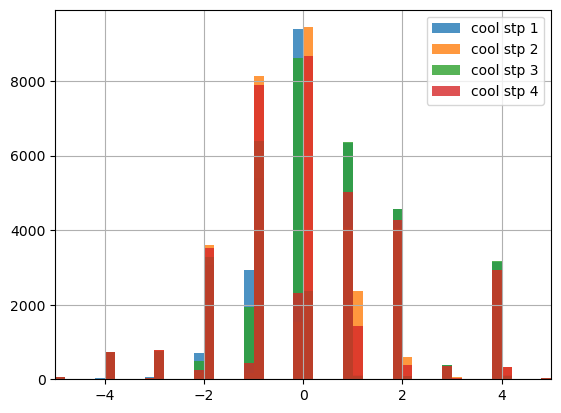

In [16]:
cool_stp = 1    # translates to meas_every_cool... * cool_stp cooling steps
for cool_stp in range(1, 5):
    plt.plot(topo_sorted[cool_stp::skip_topo,2][:], alpha=0.8, marker="o", ms=3, label=f"cool stp {cool_stp}")
plt.grid()
plt.legend()
plt.title(r"$Q_\mathrm{geom}[U]$")
plt.show()

for cool_stp in range(1,5):
    plt.hist(topo_sorted[cool_stp::skip_topo,2][:], alpha=0.8, bins=50, label=f"cool stp {cool_stp}")
plt.grid()
plt.legend()
plt.xlim(-5,5)

Text(0.5, 0, 'sample nr.')

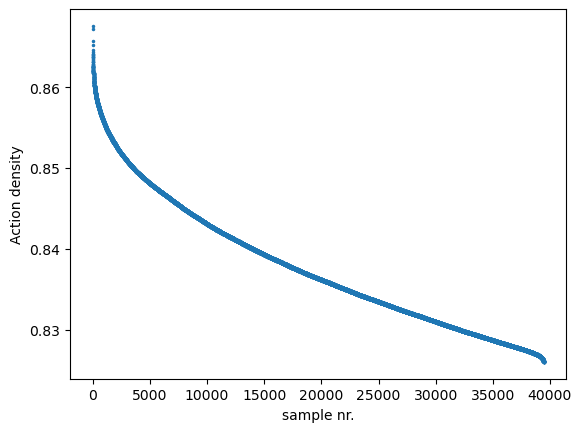

In [18]:
# progression of the action values?
plt.plot(gen_sorted[::,1], marker=".", linestyle="", ms=3)

#plt.xlim(0, 100)

plt.ylabel("Action density")
plt.xlabel("sample nr.")

# look at nested sampling Z

In [19]:
gen_data  = gen_sorted
topo_data = topo_sorted

energies = 2*gen_data[:,1]

print(gen_data.shape, "\n", topo_data.shape)

(39458, 4) 
 (434038, 8)


In [20]:
n_meas = len(gen_data)
print(n_meas)

39458


In [21]:
# similar to Simone Romiti's lattice tools: https://github.com/simone-romiti/lattice_data_tools/tree/main

# get set of Beta-distributed vals X_i
# rng = np.random.default_rng()
#t_list = rng.beta(n_live, 1, size=(n_meas,))
# x_list = np.cumprod(t_list)

## simple approach:
log_t = (-1.0/n_live_eff) * np.ones(n_meas)
t_list = np.exp(log_t)

# get log(x)
log_x = np.cumsum(log_t)
x_list = np.exp(log_x)
h_list = np.exp(log_x[:-1]) - np.exp(log_x[1:])
#print(log_x.shape)

# get log(w) (fwd definition ~ w_i = x_i-1 - x_i)
log_w = log_x  + np.log(1.0 - t_list)

In [22]:
# get log(w)
"""log_w0 = 0
log_w = [np.log(1-t_list[0])]
for i in range(1, len(t_list-1)):
    log_w0 += np.log(t_list[i-1])
    log_w.append(log_w0-np.log(1-t_list[i]))

log_w = np.array(log_w)"""

'log_w0 = 0\nlog_w = [np.log(1-t_list[0])]\nfor i in range(1, len(t_list-1)):\n    log_w0 += np.log(t_list[i-1])\n    log_w.append(log_w0-np.log(1-t_list[i]))\n\nlog_w = np.array(log_w)'

In [23]:
from scipy.special import logsumexp

In [24]:
# get normalized weights: (L=1 here since it is part of the prior!)
log_Z_unnorm = logsumexp(log_w)
log_w_norm = log_w - log_Z_unnorm

In [25]:
# from Simones tools:
def get_log_Z_curve(log_wL_normalized: np.ndarray):
    """
    The partition function is normalized to 1.
    The total weights w_i*L_i are the discrete version of the probability density function.
    The cumulative sum of the total weights gives use the cumulative density function. This function returns the log of that curve.
    """
    n_iter = log_wL_normalized.shape[0]
    s = log_wL_normalized[0]
    logZ = [s]
    for i in range(n_iter-1):
        s = np.logaddexp(s, log_wL_normalized[i+1])
        logZ.append(s)
    #---
    res = np.array(logZ)
    return res

Text(0, 0.5, 'Z')

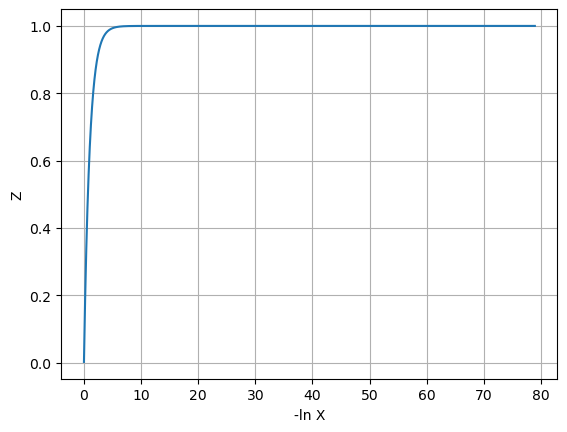

In [26]:
log_Z_curve = get_log_Z_curve(log_w_norm)
plt.plot(-log_x,np.exp(log_Z_curve))

plt.grid()
plt.xlabel("-ln X")
plt.ylabel("Z")

In [27]:
# does it do the same as the function above? yes!
log_Z = []
for i in range(len(energies)):
    log_Z.append(logsumexp(log_w[:i]))  #-energies[:i]+
log_Z = np.array(log_Z)
log_Z_norm = log_Z[-1]
log_Z -= log_Z_norm
log_Z.shape
# log_Z_tot = logsumexp(-energies+log_w)

(39458,)

Text(0, 0.5, 'Z')

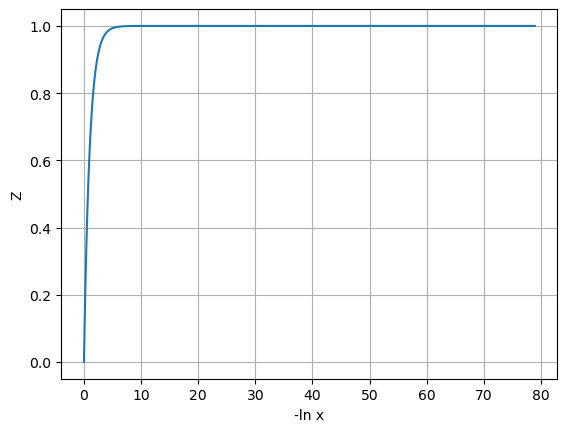

In [28]:
plt.plot(-np.log(x_list[:]), np.exp(log_Z))       #
plt.grid()
plt.xlabel("-ln x")
plt.ylabel("Z")

In [29]:
log_Z = []
for i in range(len(energies)):
    log_Z.append(logsumexp(log_w_norm[:i]))  #-energies[:i]+
log_Z = np.array(log_Z)
log_Z.shape
# log_Z_tot = logsumexp(-energies+log_w)

(39458,)

Text(0, 0.5, 'norm. weights')

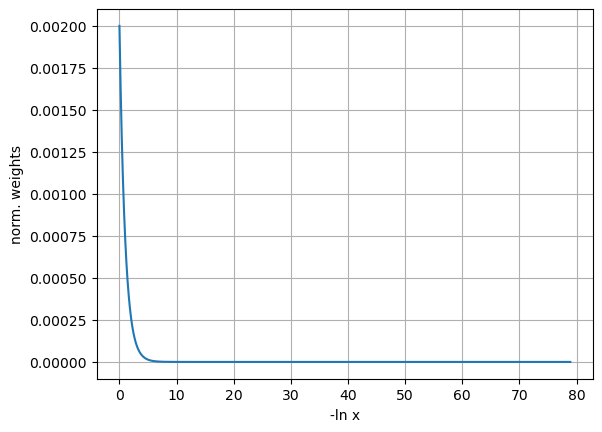

In [30]:
plt.plot(-np.log(x_list[:]),np.exp(log_w_norm))
plt.grid()
plt.xlabel("-ln x")
plt.ylabel("norm. weights")

Text(0, 0.5, 'Z')

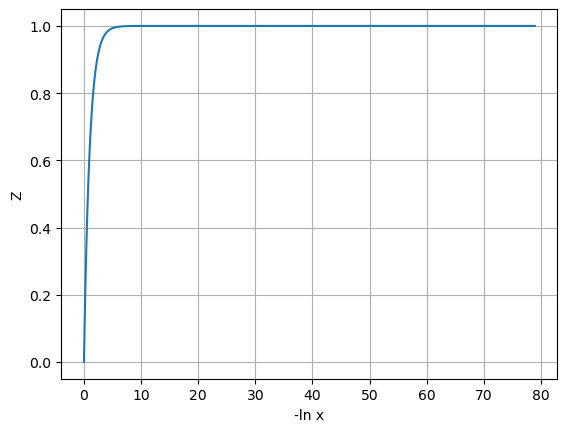

In [31]:
plt.plot(-np.log(x_list[:]), np.exp(log_Z))       #
plt.grid()
plt.xlabel("-ln x")
plt.ylabel("Z")

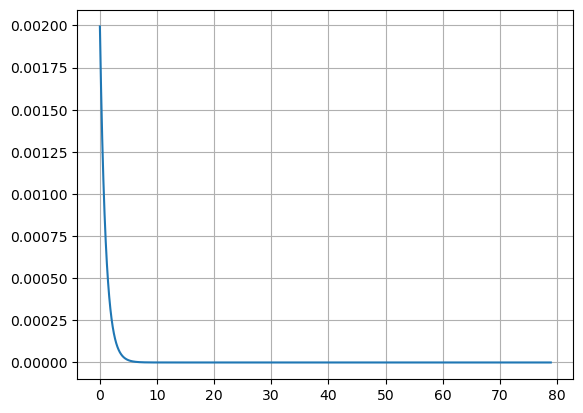

In [32]:
plt.plot(-np.log(x_list[1:]), h_list)       #np.exp(Z_can)*
plt.grid()

# look at the energy
$$ 
    \langle O \rangle = \frac{1}{Z}\sum_i L_i^{\Delta\beta} w_i O_i
$$

Text(0, 0.5, 'counts')

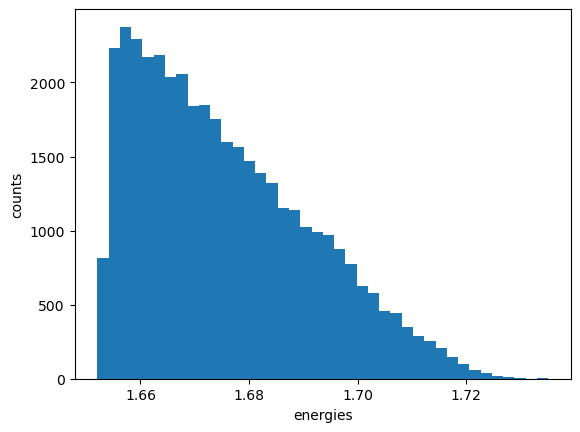

In [33]:
energies = 2*gen_data[:,1]
_=plt.hist(energies, bins=40)
plt.xlabel("energies")
plt.ylabel("counts")

In [34]:
# avg_obs = np.sum(np.exp(log_w_norm)*energies)
avg_obs = np.sum(np.exp(log_w_norm+np.log(energies)))
print(avg_obs)

print("Thesis result for b=0.6, L=72, N=21:\t1.716722(2)")

1.716910183283351
Thesis result for b=0.6, L=72, N=21:	1.716722(2)


In [35]:
1.716722/2

0.858361

# Look at the geometric cooled charge

Can we also get the correct $\langle Q^2 \rangle?

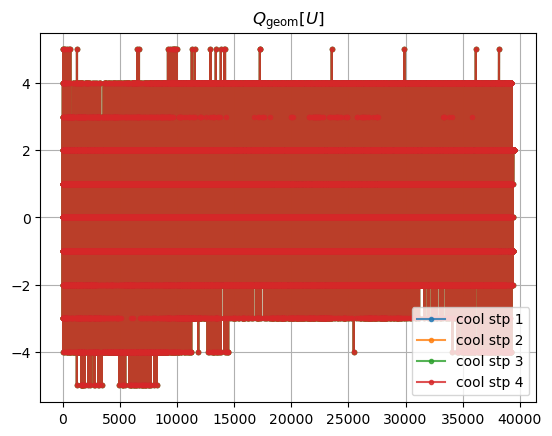

(-5.0, 5.0)

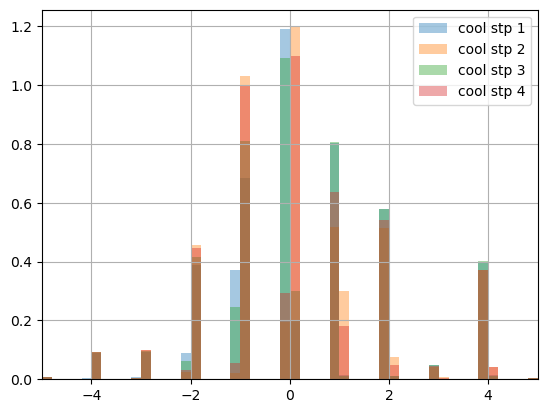

In [36]:
cool_stp = 1    # translates to meas_every_cool... * cool_stp cooling steps
topo_idx = 2        # 2 geom, 6 nongeom
for cool_stp in range(1, 5):
    plt.plot(topo_sorted[cool_stp::skip_topo,topo_idx][:40000], alpha=0.8, marker="o", ms=3, label=f"cool stp {cool_stp}")
plt.grid()
plt.legend()
plt.title(r"$Q_\mathrm{geom}[U]$")
plt.show()

for cool_stp in range(1,5):
    plt.hist(topo_sorted[cool_stp::skip_topo,topo_idx][:], alpha=0.4, bins=50, label=f"cool stp {cool_stp}", density=True)
plt.grid()
plt.legend()
plt.xlim(-5,5)

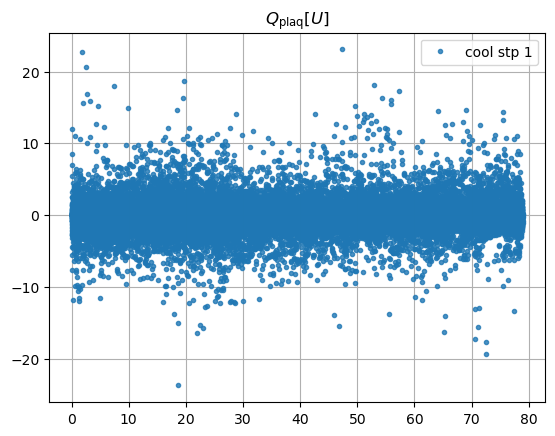

In [37]:
cool_stp = 1    # translates to meas_every_cool... * cool_stp cooling steps
topo_idx = 6        # 2 geom, 6 nongeom

plt.plot(-np.log(x_list[:]), topo_sorted[cool_stp::skip_topo,topo_idx][:], alpha=0.8, marker="o", linestyle="None", ms=3, label=f"cool stp {cool_stp}")
plt.grid()
plt.legend()
plt.title(r"$Q_\mathrm{plaq}[U]$")
plt.show()

In [38]:
c_step = 4
obs = topo_data[c_step::skip_topo,2]

avg_obs = np.sum(np.exp(log_w_norm)*obs)
print(avg_obs)

print("Thesis result for b=0.6, L=72, N=21:\t0.002(3)")
print("This is perhaps skewed by the fact that we are in the end trapped in one topological sector...!")

0.11218581973168439
Thesis result for b=0.6, L=72, N=21:	0.002(3)
This is perhaps skewed by the fact that we are in the end trapped in one topological sector...!


# Look at $\xi_L$

And what about the correlation length? 

$$
\xi_L^2 = \frac{1}{4\sin^2(k/2)} \left[ \frac{\tilde{G}_L(0)}{\tilde{G}_L(k)} - 1\right] , \ \ k= 2\pi/L
$$

Some of the G_L are negative? Should that be allowed?

In [39]:
k = 2*np.pi / L

In [40]:
obs_0 = gen_data[:,2]
obs_k = gen_data[:,3]

#avg_obs_0 = np.sum(np.exp(log_w_norm)*obs_0)
#avg_obs_k = np.sum(np.exp(log_w_norm)*obs_k)

avg_obs_0 = np.sum(np.sign(obs_0)*np.exp(log_w_norm+np.log(np.abs(obs_0))))
avg_obs_k = np.sum(np.sign(obs_k)*np.exp(log_w_norm+np.log(np.abs(obs_k))))

xi_L2 = 1 / (4 * np.sin(k/2)**2) * (avg_obs_0/avg_obs_k - 1.)
print(f"xi_L={np.sqrt(xi_L2)}")

print("Thesis result for b=0.6, L=72, N=21:\t2.895(7)")

xi_L=3.993402869882989
Thesis result for b=0.6, L=72, N=21:	2.895(7)
